In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Import the dataset
df = pd.read_excel("ABS Tech Case 2026_Data.xlsx")

# Capitalize entries in column for hispanic/latino
df["HispanicLatino"] = df["HispanicLatino"].str.capitalize()

In [16]:
df.head()

,Employee.Name,PerfScore,PerformanceScore,GenderID,Salary,Termd,PositionID,Position,State,Zip,...,AIUse,AIConf,TrainHours,WLF,InnoCont,technical_score,personal_score,interpersonal_score,talent_score,is_talent
0,"Adinolfi, Wilson K",4,Exceeds,1,62506,0,19,Production Technician I,MA,1960,...,2,2,88,4,5,10.25,1.180,1.00,5.67000,0
1,"Ait Sidi, Karthikeyan",3,Fully Meets,1,104437,1,27,Sr. DBA,MA,2148,...,5,3,128,3,5,15.50,1.048,0.53,8.14450,1
2,"Akinkuolie, Sarah",3,Fully Meets,0,64955,1,20,Production Technician II,MA,1810,...,2,1,53,3,3,6.35,0.951,0.38,3.50775,0
3,"Alagbe,Trina",3,Fully Meets,0,64991,0,19,Production Technician I,MA,1886,...,2,2,69,3,3,8.30,0.942,0.81,4.58800,0
4,"Anderson, Carol",3,Fully Meets,0,50825,1,19,Production Technician I,MA,2169,...,2,2,55,4,2,6.50,1.100,0.81,3.72750,0


In [4]:
# Adding the calculated scores to the DataFrame
df["technical_score"] = ( 0.15 * df["TechLev"] + 0.10 * df["TrainHours"] +0.05 * df["AIUse"] + 0.05 * df["AIConf"] +0.10 * df["InnoCont"] +0.10 * df["SpecialProjectsCount"])
df["personal_score"] = (0.05 * df["EngagementSurvey"] +0.05 * df["WLF"] +0.15 * df["PerfScore"] +0.05 * df["JobStr"])
df["interpersonal_score"] = (0.12 * (df["Feedback"] + df["Trust"]) / 2 +0.06 * df["TeamIden"] +0.05 * df["Network"] +0.02 * df["ProjColl"])
df["talent_score"] = (0.50 * df["technical_score"] +0.25 * df["personal_score"] +0.25 * df["interpersonal_score"])

# Define the talent threshold
threshold = df["talent_score"].quantile(0.80)
df["is_talent"] = (df["talent_score"] >= threshold).astype(int)

## Question 1

In [14]:
def talent_demographic_summary(data):

    talent_col = "is_talent"

    demographics = [
        "GenderID",
        "RaceDesc",
        "HispanicLatino",
        "Department",
        "ManPos",
        "Remote",
        "Position",
        "TechLev"
    ]
    
    results = {}
    total_employees = len(df)
    total_talents = df[talent_col].sum()
    
    for var in demographics:
            
        summary = (
            df.groupby(var)
            .agg(
                total_employees=(talent_col, "count"),
                talents=(talent_col, "sum")
            )
        )
        
        summary["pct_talents_within_group"] = summary["talents"] / summary["total_employees"]
        summary["workforce_share"] = summary["total_employees"] / total_employees
        summary["talent_share_total"] = summary["talents"] / total_talents
        
        # Representation ratio:
        # % of all talents from group / % workforce from group
        summary["representation_ratio"] = (
            summary["talent_share_total"] / summary["workforce_share"]
        )
        
        summary = summary.sort_values("pct_talents_within_group", ascending=False)
        
        results[var] = summary.reset_index()
    
    return results

demographic_summary = talent_demographic_summary(df)

# demographic_summary["GenderID"]
# demographic_summary["RaceDesc"]
# demographic_summary["HispanicLatino"]
demographic_summary["Department"]
# demographic_summary["ManPos"]
# demographic_summary["Remote"]
# demographic_summary["Position"]
# demographic_summary["TechLev"]


,Department,total_employees,talents,pct_talents_within_group,workforce_share,talent_share_total,representation_ratio
0,IT/IS,50,37,0.740000,0.160772,0.587302,3.653016
1,Software Engineering,11,4,0.363636,0.035370,0.063492,1.795094
2,Admin Offices,9,3,0.333333,0.028939,0.047619,1.645503
3,Sales,31,3,0.096774,0.099678,0.047619,0.477727
4,Production,209,16,0.076555,0.672026,0.253968,0.377914
5,Executive Office,1,0,0.000000,0.003215,0.000000,0.000000


## Question 2

In [11]:
def turnover1(data, group_col):
    tmp = data.copy()
    summary = (
        tmp.groupby(group_col)["Termd"]
           .agg(count= "size",leavers= "sum",stayers= lambda x: (1 - x).sum(),turnoverrate = "mean")
    )
    summary["turnoverrate"] = (summary["turnoverrate"]* 100)
    summary = summary.sort_values("turnoverrate",ascending=False)
    return summary

In [12]:
department = turnover1(df, "Department")
department

,count,leavers,stayers,turnoverrate
Department,,,,
Production,209,83,126,39.712919
Software Engineering,11,4,7,36.363636
Admin Offices,9,2,7,22.222222
IT/IS,50,10,40,20.000000
Sales,31,5,26,16.129032
Executive Office,1,0,1,0.000000


## Question 3

Overall Turnover: 0.33440514469453375
Talent Turnover: 0.09523809523809523
Non-Talent Turnover: 0.3951612903225806


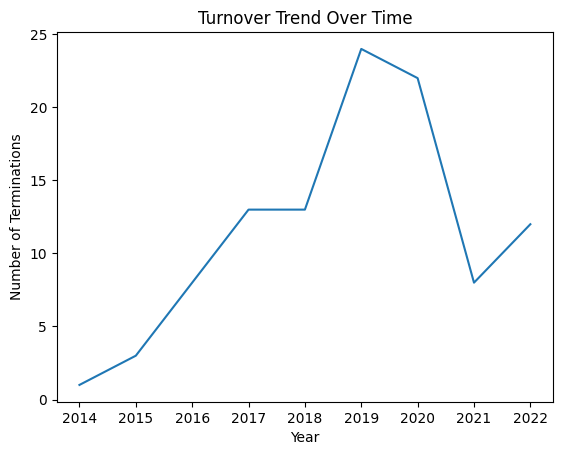

In [9]:
# Normalize variables (0–1 scale)
def normalize(x):
    return (x - x.min()) / (x.max() - x.min())

# --- Technical abilities (50%)
technical = (
    0.15 * normalize(df["TechLev"]) +
    0.10 * normalize(df["TrainHours"]) +
    0.05 * normalize((df["AIUse"] + df["AIConf"]) / 2) +
    0.10 * normalize(df["InnoCont"]) +
    0.10 * normalize(df["SpecialProjectsCount"])
)

# --- Personal abilities (25%)
personal = (
    0.05 * normalize(df["EngagementSurvey"]) +
    0.05 * normalize(df["WLF"]) +
    0.15 * normalize(df["PerfScore"]) +
    0.05 * (1 - normalize(df["JobStr"]))  # lower stress is better
)

# --- Interpersonal abilities (25%)
interpersonal = (
    0.12 * normalize((df["Feedback"] + df["Trust"]) / 2) +
    0.06 * normalize(df["TeamIden"]) +
    0.05 * normalize(df["Network"]) +
    0.02 * normalize(df["ProjColl"])
)

# Final Talent Score
df["TalentScore"] = technical + personal + interpersonal

# Identify Talent (Top 20%)
threshold = df["TalentScore"].quantile(0.80)
df["IdentifiedTalent"] = (df["TalentScore"] >= threshold).astype(int)

# Compare Turnover Rates
overall_turnover = df["Termd"].mean()
talent_turnover = df[df["IdentifiedTalent"] == 1]["Termd"].mean()
non_talent_turnover = df[df["IdentifiedTalent"] == 0]["Termd"].mean()

print("Overall Turnover:", overall_turnover)
print("Talent Turnover:", talent_turnover)
print("Non-Talent Turnover:", non_talent_turnover)

# Turnover Trend Over Time
df["DateofTermination"] = pd.to_datetime(df["DateofTermination"], errors="coerce")
df["TerminationYear"] = df["DateofTermination"].dt.year

turnover_by_year = df[df["Termd"] == 1].groupby("TerminationYear").size()

# Plot trend
plt.figure()
turnover_by_year.plot(kind="line")
plt.title("Turnover Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Terminations")
plt.show()

## Question 4

In [4]:
answer_csv = pd.read_csv('HR_Q4.csv')
answer_csv

,Metric,Mean_Diff,Mean_PctDiff,StdDev_Diff,StdDev_PctDiff,Median_Diff,Median_PctDiff,Min_Diff,Min_PctDiff,Max_Diff,Max_PctDiff
0,AIConf,0.610562,38.93%,0.252624,30.52%,1.00,100.00%,0.00,0.00%,0.0,0.00%
1,AIUse,0.480567,22.74%,0.103868,11.35%,1.00,50.00%,0.00,0.00%,0.0,0.00%
2,Absences,-1.123628,-10.26%,0.051187,0.88%,-1.00,-9.09%,0.00,0.00%,0.0,0.00%
3,CarOpp,1.035189,56.58%,0.165571,18.67%,1.00,50.00%,0.00,0.00%,1.0,25.00%
4,DaysLateLast30,-0.119236,-29.15%,-0.260578,-19.76%,0.00,NaN,0.00,NaN,0.0,0.00%
5,EmpSatisfaction,-0.004007,-0.10%,0.075664,8.82%,0.00,0.00%,-1.00,-50.00%,0.0,0.00%
6,EngagementSurvey,-0.060421,-1.45%,0.071027,10.00%,0.02,0.47%,-1.22,-52.14%,0.0,0.00%
7,Feedback,0.690437,26.08%,0.002019,0.18%,0.00,0.00%,0.00,0.00%,0.0,0.00%
8,InnoCont,0.313351,11.68%,0.079444,9.81%,0.00,0.00%,0.00,0.00%,0.0,0.00%
9,JobStr,0.125878,4.24%,-0.181636,-17.21%,0.00,0.00%,0.00,0.00%,0.0,0.00%


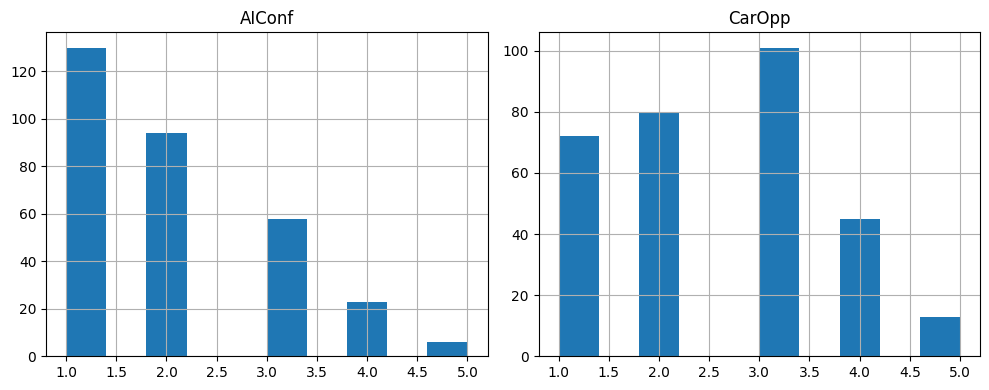

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Frequency of AI tool use in daily work (1 = never, …, 5 = constantly)
df['AIConf'].hist(ax=axes[0])
axes[0].set_title('AIConf')

# The extent to which there are clear and accessible career opportunities 
# within the organization (1 = very few opportunities, …, 5 = a lot of opportunities)
df['CarOpp'].hist(ax=axes[1])
axes[1].set_title('CarOpp')

plt.tight_layout()
plt.show()

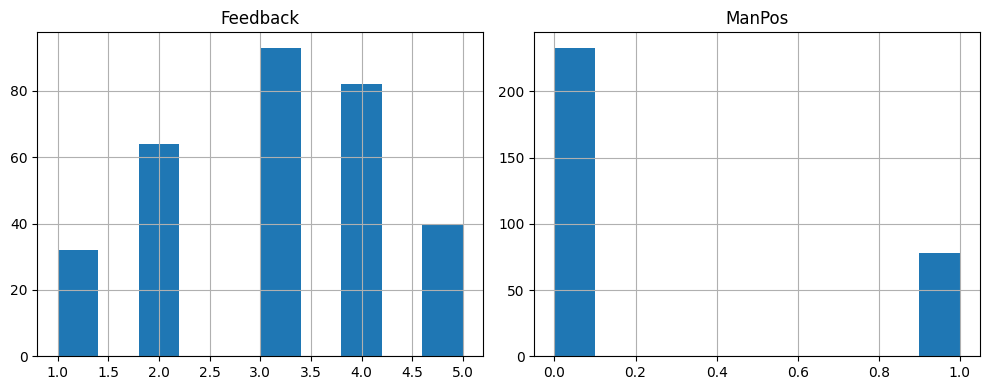

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# The extent to which one is willing to provide suggestions and feedback to
# the employer and the team (1 = no willingness at all, …, 5 = extremely high willingness)
df['Feedback'].hist(ax=axes[0])
axes[0].set_title('Feedback')

# Was/is the employee in a management position (1 = Yes, 0 = No)
df['ManPos'].hist(ax=axes[1])
axes[1].set_title('ManPos')

plt.tight_layout()
plt.show()